# Adult Dataset — Certified Counterfactual Sampling

Pipeline:
1. Load a trained `TabularClassifier` from a Lightning checkpoint.
2. Embed the training set into the continuous embedding space (70-dim for Adult).
3. **K-medoids** in embedding space → select K spread-out representatives per class.
4. Build `CertifiedAtlas` on `model.net` (pure ReLU MLP, LiRPA-compatible) using the K medoids per class.
5. For a query point (class 0: income ≤50K), find the nearest certified counterfactual (class 1: income >50K) in embedding space.
6. Decode back to original feature values (nearest-category for categoricals).
7. Re-embed the decoded point and verify it falls inside the certified polytope.

**Why k-medoids?** With 39k training points, random subsampling to 500/class produces dense clusters where many polytopes overlap. K-medoids selects *spread-out* representatives that tile the embedding space more uniformly — fewer polytopes, less QP work at query time, and better coverage per polytope.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import pandas as pd
from torch.utils.data import TensorDataset

from training.lit_classifier import LitClassifier
from training.datamodules.adult import AdultDataModule, _ALL_COLS, INPUT_TYPES, _CATEGORICAL, _NUMERICAL, CARDINALITIES
from models.classifiers import TabularClassifier
from preimage_sampling import CertifiedAtlas

# DEVICE = 'cuda'  # atlas runs on CPU; change to 'cuda' if preferred
DEVICE = 'cpu'
CKPT  = '../checkpoints/adult_classifier/last-v2.ckpt'

## 1. Load model

In [2]:
# LitClassifier uses save_hyperparameters(ignore=["model"]), so the model architecture
# is not stored in the checkpoint — must be provided explicitly at load time.
tabular_model = TabularClassifier(
    input_types=INPUT_TYPES,
    cardinalities=CARDINALITIES,
    embedding_dim=1,
    hidden_dims=[64, 32],
    num_classes=2,
)

lit = LitClassifier.load_from_checkpoint(CKPT, model=tabular_model, map_location=DEVICE)
model = lit.model.eval().to(DEVICE)

print(f'embed_dim : {model.embed_dim}')
print(f'net       : {model.net}')

embed_dim : 14
net       : Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


## 2. Load & preprocess data

In [3]:
dm = AdultDataModule(data_dir='../data/', batch_size=256, num_workers=0)
dm.setup()

X_train, y_train = dm.train_ds.tensors
X_test,  y_test  = dm.test_ds.tensors
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([39074, 14]), Test: torch.Size([4884, 14])


## 3. Embed training set & K-Medoids downsampling

In [4]:
with torch.no_grad():
    Z_train = model.embed(X_train.to(DEVICE)).cpu()

embedded_ds = TensorDataset(Z_train, y_train)
print(f'Embedded training set: {Z_train.shape}')

Embedded training set: torch.Size([39074, 14])


In [5]:
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_BACKEND = 'sklearn_extra'
except ImportError:
    KMedoids = None
    KMEDOIDS_BACKEND = 'kmeans+nn'
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances

print(f'K-medoids backend: {KMEDOIDS_BACKEND}')

SEED = 42
K_PER_CLASS = 100


def fit_kmedoids(X, k, seed=SEED):
    """Return indices of k medoids in X (actual data points nearest each cluster centre)."""
    k = min(k, len(X))
    if KMEDOIDS_BACKEND == 'sklearn_extra':
        km = KMedoids(n_clusters=k, metric='euclidean', method='alternate', random_state=seed)
        km.fit(X)
        return km.medoid_indices_
    else:
        km = KMeans(n_clusters=k, random_state=seed, n_init='auto')
        km.fit(X)
        return pairwise_distances(km.cluster_centers_, X).argmin(axis=1)


# Cluster each class independently in the 70-dim embedding space
medoid_z_list, medoid_y_list = [], []
for c in range(2):
    mask = (y_train == c).numpy()
    Z_c = Z_train[mask].numpy()
    med_idx = fit_kmedoids(Z_c, K_PER_CLASS)
    medoid_z_list.append(torch.tensor(Z_c[med_idx], dtype=torch.float32))
    medoid_y_list.append(torch.full((len(med_idx),), c, dtype=torch.long))
    print(f'  Class {c}: {mask.sum():>6d} embedded points  →  {len(med_idx)} medoids')

medoid_z_all = torch.cat(medoid_z_list)
medoid_y_all = torch.cat(medoid_y_list)
medoid_ds = TensorDataset(medoid_z_all, medoid_y_all)

print(f'\nFull embedded dataset  : {len(embedded_ds)} samples')
print(f'Medoid dataset         : {len(medoid_ds)} samples  ({100*len(medoid_ds)/len(embedded_ds):.2f}% of full)')

K-medoids backend: kmeans+nn
  Class 0:  29730 embedded points  →  100 medoids
  Class 1:   9344 embedded points  →  100 medoids

Full embedded dataset  : 39074 samples
Medoid dataset         : 200 samples  (0.51% of full)


In [6]:
atlas = CertifiedAtlas(model.net, medoid_ds, device=DEVICE)
atlas.build(
    eps=0.5,
    norm=1,
    batch_size=256,
)
print(atlas.summary())

Building certified atlas (eps=0.5, L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:00<00:00, 17.45it/s]

  Building BVH spatial indices...
    Class 0: 100 polytopes, tree depth 8
    Class 1: 100 polytopes, tree depth 8
Done! Total: 200 polytopes across 2 classes
CertifiedAtlas Summary
Classes: 2
Perturbation: eps=0.5, L1 norm
Device: cpu

  Class 0:  100 polytopes (BVH depth 8)
  Class 1:  100 polytopes (BVH depth 8)

Total polytopes: 200


## 4. Pick a query point (predicted class 0: income ≤50K)

In [7]:
with torch.no_grad():
    preds_test = model(X_test.to(DEVICE)).argmax(dim=1).cpu()

# Take the first test sample the model predicts as class 0
query_idx = (preds_test == 0).nonzero(as_tuple=True)[0][0].item()
x_query = X_test[query_idx]   # (14,)
print(f'Query index: {query_idx}, true label: {y_test[query_idx].item()}, predicted: {preds_test[query_idx].item()}')

with torch.no_grad():
    z_query = model.embed(x_query.unsqueeze(0).to(DEVICE)).squeeze(0).cpu().numpy()
print(f'z_query shape: {z_query.shape}')

Query index: 0, true label: 0, predicted: 0
z_query shape: (14,)


## 5. Find counterfactual in embedding space (target: class 1, income >50K)

In [8]:
# --- Feature → embedding-dim mapping ---
print(f"{'Feature':<20} {'Type':<12} {'Emb dims'}")
print('-' * 45)
for col, t, (s, e) in zip(_ALL_COLS, INPUT_TYPES, model._slices):
    print(f'{col:<20} {t:<12} [{s}:{e}]  ({e-s} dim{"s" if e-s>1 else ""})')

# Features that should NOT change (immutable / non-actionable)
# model.feature_dims() maps names → embedding-space indices
FIXED_FEATURES = ['race', 'sex', 'native-country']
fixed_dims = model.feature_dims(FIXED_FEATURES, _ALL_COLS)
print(f'\nFixed features : {FIXED_FEATURES}')
print(f'Fixed emb dims : {fixed_dims.tolist()}  ({len(fixed_dims)} total)')

result = atlas.find_counterfactual(
    z_query, target_class=1, method='bvh',
    fixed_dims=fixed_dims,
    solver_maxiter=3000
)
print(result)

Feature              Type         Emb dims
---------------------------------------------
age                  numerical    [0:1]  (1 dim)
workclass            categorical  [1:2]  (1 dim)
fnlwgt               numerical    [2:3]  (1 dim)
education            categorical  [3:4]  (1 dim)
education-num        numerical    [4:5]  (1 dim)
marital-status       categorical  [5:6]  (1 dim)
occupation           categorical  [6:7]  (1 dim)
relationship         categorical  [7:8]  (1 dim)
race                 categorical  [8:9]  (1 dim)
sex                  categorical  [9:10]  (1 dim)
capital-gain         numerical    [10:11]  (1 dim)
capital-loss         numerical    [11:12]  (1 dim)
hours-per-week       numerical    [12:13]  (1 dim)
native-country       categorical  [13:14]  (1 dim)

Fixed features : ['race', 'sex', 'native-country']
Fixed emb dims : [8, 9, 13]  (3 total)
CounterfactualResult(x_cf=array([ 0.2420148 ,  0.43554252, -0.64330405,  1.20757759,  1.13456511,
       -1.65680885, -0.0065

## 6. Decode back to original features

In [9]:
assert result.success, 'No counterfactual found — try increasing eps or max_samples_per_class'

z_cf = torch.tensor(result.x_cf, dtype=torch.float32).unsqueeze(0)
x_cf = model.decode(z_cf).squeeze(0)   # (14,) — categorical dims are nearest integer indices
print(f'x_cf: {x_cf}')

x_cf: tensor([ 0.2420,  3.0000, -0.6433,  9.0000,  1.1346,  2.0000,  9.0000,  0.0000,
         4.0000,  1.0000, -0.1441, -0.2171,  2.8727, 28.0000])


## 7. Re-embed & verify certification

Check whether the re-embedded decoded point falls inside the certified polytope found by the atlas.

In [10]:
with torch.no_grad():
    z_cf_re = model.embed(x_cf.unsqueeze(0).to(DEVICE)).squeeze(0).cpu().numpy()

# Retrieve the anchor polytope
bd = atlas.bounds[1]
A  = bd['lA'][result.anchor_idx]     # (n_constraints, 70)
b  = bd['lbias'][result.anchor_idx]  # (n_constraints,)

margins = A @ z_cf_re + b
is_certified = bool(np.all(margins >= -1e-6))

# Also check model prediction on the decoded CF
with torch.no_grad():
    pred_cf = model(x_cf.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()

print(f'Re-embedded CF certified : {is_certified}  (min margin: {margins.min():.4f})')
print(f'Model prediction on x_cf : {pred_cf}  (expected 1)')

Re-embedded CF certified : False  (min margin: -0.0788)
Model prediction on x_cf : 1  (expected 1)


## 8. Human-readable comparison

In [11]:
def to_human_readable(x_tensor, dm):
    """Convert a raw feature tensor (14,) to a readable dict."""
    x = x_tensor.numpy()
    num_cols = [c for c in _ALL_COLS if c in _NUMERICAL]
    num_idx  = [_ALL_COLS.index(c) for c in num_cols]
    
    # Inverse-scale numerical features
    x_num_scaled = x[num_idx].reshape(1, -1)
    x_num_orig   = dm.scaler.inverse_transform(x_num_scaled)[0]
    
    row = {}
    num_iter = iter(x_num_orig)
    for col, t in zip(_ALL_COLS, INPUT_TYPES):
        i = _ALL_COLS.index(col)
        if t == 'numerical':
            row[col] = round(float(next(num_iter)), 2)
        else:
            cat_idx = int(x[i])
            row[col] = dm.label_encoders[col].classes_[cat_idx]
    return row

orig_row = to_human_readable(x_query.cpu(), dm)
cf_row   = to_human_readable(x_cf.cpu(), dm)

df = pd.DataFrame({'original': orig_row, 'counterfactual': cf_row})
df['changed'] = df['original'] != df['counterfactual']
df

,original,counterfactual,changed
age,24.0,42.0,True
workclass,Private,Private,False
fnlwgt,333505.0,121352.0,True
education,HS-grad,Bachelors,True
education-num,9.0,13.0,True
marital-status,Married-spouse-absent,Married-civ-spouse,True
occupation,Transport-moving,Prof-specialty,True
relationship,Own-child,Husband,True
race,White,White,False
sex,Male,Male,False


## 9. 2D PCA visualization of the embedding space

Embedding dim  : 14
Fixed dims     : 3  [8, 9, 13]
Free dims      : 11  (used for PCA)
Background points: 3000,  misclassified: 620 (20.7%)
Polytopes projected — class 0: 99/100, class 1: 92/100


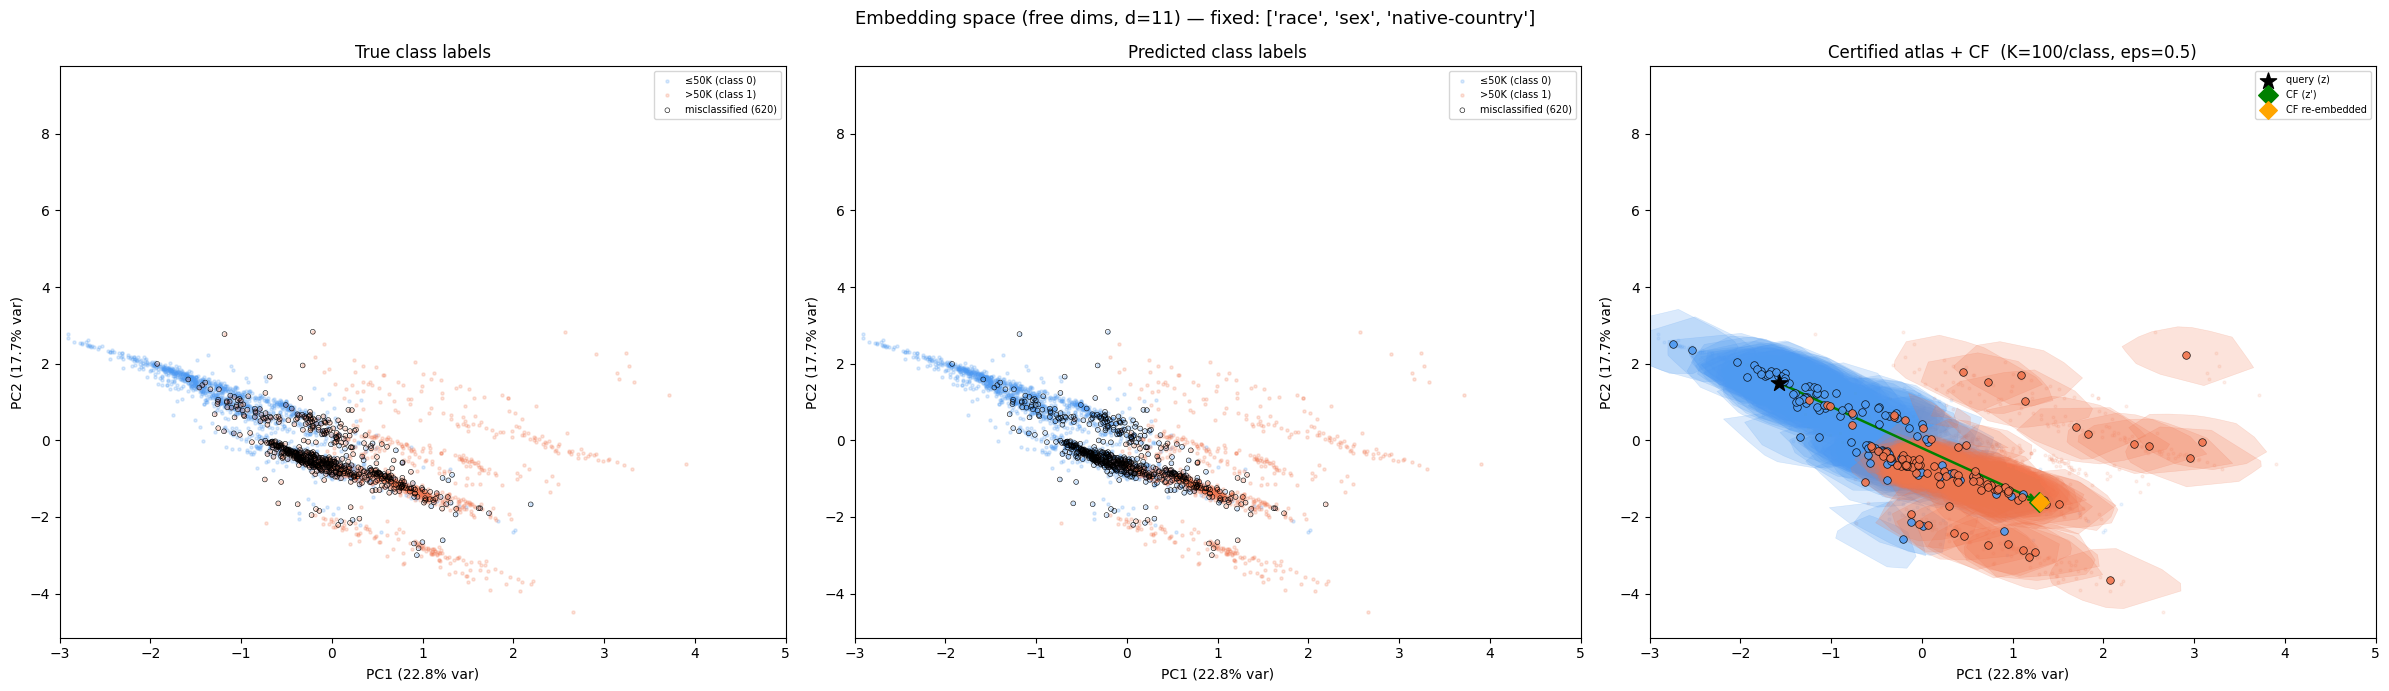

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull, QhullError
from matplotlib.patches import Polygon as MplPolygon

# Free dimensions: drop fixed ones (zero variance in constrained CF search)
free_dims = np.array([i for i in range(model.embed_dim) if i not in set(fixed_dims.tolist())])
print(f'Embedding dim  : {model.embed_dim}')
print(f'Fixed dims     : {len(fixed_dims)}  {fixed_dims.tolist()}')
print(f'Free dims      : {len(free_dims)}  (used for PCA)')

# --- Subsample background points, keep FULL embedding for predictions ---
N_PLOT = 3000
rng = np.random.default_rng(0)
idx0 = rng.choice((y_train == 0).nonzero(as_tuple=True)[0].numpy(), N_PLOT // 2, replace=False)
idx1 = rng.choice((y_train == 1).nonzero(as_tuple=True)[0].numpy(), N_PLOT // 2, replace=False)
Z_plot_full = torch.cat([Z_train[idx0], Z_train[idx1]])  # full embed, needed for predictions

y_true_plot = np.array([0] * (N_PLOT // 2) + [1] * (N_PLOT // 2))

with torch.no_grad():
    y_pred_plot = model.net(Z_plot_full.to(DEVICE)).argmax(dim=1).cpu().numpy()

n_wrong = (y_true_plot != y_pred_plot).sum()
print(f'Background points: {N_PLOT},  misclassified: {n_wrong} ({100*n_wrong/N_PLOT:.1f}%)')

# --- Fit PCA on free dims only ---
Z_plot_free = Z_plot_full.numpy()[:, free_dims]
pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Z_plot_free)
explained = pca.explained_variance_ratio_

# Project special points
Z2_med     = pca.transform(medoid_z_all.numpy()[:, free_dims])
z_query_2d = pca.transform(z_query[free_dims].reshape(1, -1))[0]
z_cf_2d    = pca.transform(result.x_cf[free_dims].reshape(1, -1))[0]
z_cf_re_2d = pca.transform(z_cf_re[free_dims].reshape(1, -1))[0]

# --- Project atlas polytopes to 2D (MC sampling inside eps-box + halfspace filter) ---
N_MC = 500
rng2 = np.random.default_rng(1)
polytope_hulls = {0: [], 1: []}
for cls in [0, 1]:
    bd = atlas.bounds[cls]
    for i in range(len(bd['X'])):
        center = bd['X'][i]
        lA, lb = bd['lA'][i], bd['lbias'][i]
        t = rng2.uniform(-atlas.eps, atlas.eps, (N_MC, len(free_dims)))
        Z_full = np.tile(center, (N_MC, 1))
        Z_full[:, free_dims] += t
        ok = np.all(Z_full @ lA.T + lb >= 0, axis=1)
        Z_ok_free = Z_full[ok][:, free_dims]
        if len(Z_ok_free) < 3:
            continue
        pts_2d = pca.transform(Z_ok_free)
        try:
            hull = ConvexHull(pts_2d)
            polytope_hulls[cls].append(pts_2d[hull.vertices])
        except QhullError:
            pass

print(f'Polytopes projected — class 0: {len(polytope_hulls[0])}/{len(atlas.bounds[0]["X"])}, '
      f'class 1: {len(polytope_hulls[1])}/{len(atlas.bounds[1]["X"])}')

# --- Plot: 1×3 — true labels | predicted labels | atlas+CF ---
colors = {0: '#4e9af1', 1: '#f1754e'}
labels_cls = {0: '≤50K (class 0)', 1: '>50K (class 1)'}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def scatter_classes(ax, y_colors, title):
    for cls in [0, 1]:
        mask = y_colors == cls
        ax.scatter(Z2[mask, 0], Z2[mask, 1], c=colors[cls],
                   alpha=0.2, s=5, label=labels_cls[cls])
    # Highlight misclassified points
    wrong = y_true_plot != y_pred_plot
    ax.scatter(Z2[wrong, 0], Z2[wrong, 1],
               edgecolors='black', facecolors='none', s=12, linewidths=0.4,
               label=f'misclassified ({wrong.sum()})', zorder=3)
    ax.set_xlabel(f'PC1 ({explained[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({explained[1]:.1%} var)')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=7)

scatter_classes(axes[0], y_true_plot,  'True class labels')
scatter_classes(axes[1], y_pred_plot,  'Predicted class labels')

# Atlas + CF panel
ax = axes[2]
for cls in [0, 1]:
    mask = y_true_plot == cls
    ax.scatter(Z2[mask, 0], Z2[mask, 1], c=colors[cls], alpha=0.1, s=4)

for cls in [0, 1]:
    for verts in polytope_hulls[cls]:
        patch = MplPolygon(verts, closed=True,
                           facecolor=colors[cls], edgecolor=colors[cls],
                           alpha=0.20, linewidth=0.4)
        ax.add_patch(patch)

for cls in [0, 1]:
    mask_med = (medoid_y_all == cls).numpy()
    ax.scatter(Z2_med[mask_med, 0], Z2_med[mask_med, 1],
               c=colors[cls], s=30, alpha=0.9,
               edgecolors='black', linewidth=0.5, zorder=4)

ax.scatter(*z_query_2d, c='black',  s=150, zorder=5, marker='*', label='query (z)')
ax.scatter(*z_cf_2d,    c='green',  s=100, zorder=5, marker='D', label="CF (z')")
ax.scatter(*z_cf_re_2d, c='orange', s=80,  zorder=5, marker='D', label='CF re-embedded')
ax.annotate('', xy=z_cf_2d, xytext=z_query_2d,
            arrowprops=dict(arrowstyle='->', color='green', lw=1.8))
ax.set_xlabel(f'PC1 ({explained[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} var)')
ax.set_title(f'Certified atlas + CF  (K={K_PER_CLASS}/class, eps={atlas.eps})')
ax.legend(loc='best', fontsize=7)



# Set xlim -3, 5
axes[0].set_xlim(-3, 5)
axes[1].set_xlim(-3, 5)
axes[2].set_xlim(-3, 5)



plt.suptitle(f'Embedding space (free dims, d={len(free_dims)}) — fixed: {FIXED_FEATURES}',
             fontsize=13)
plt.tight_layout()
plt.show()